# COP509 Notebook 1: Task 1 Search System

This notebook is the assessed source of truth for **Task 1: Search system**. It demonstrates passage retrieval over the coursework search evaluation corpus without requiring the optional web interface.

The pipeline is:

1. Discover the full available preset corpus, then select the coursework-given search evaluation subset
2. Extract and preprocess PDF page text
3. Segment documents into searchable passage chunks
4. Build ranked search over the chunks
5. Evaluate retrieval quality with a fixed 50-query bank
6. Provide an `ipywidgets` search demo, plus static examples for PDF readability

The shared project modules in `src/` are used directly so the notebook stays consistent with the rest of the project.

## 1. Dataset, Scope And Reproducibility

The full available project corpus contains **8 document pairs / 16 PDFs**. These are used by the extended project interface and by the final extraction, alignment and classification evidence in Notebook 2.

The coursework search evaluation corpus contains **5 document pairs / 10 PDFs**. The Task 1 evaluation bank (`data/ground_truth/qa_matrix_queries.json`) was built for those coursework-given pairs, so this notebook runs the 50-query QA matrix over that 10-PDF subset only.

Extension pairs remain visible in the inventory below. They are not mixed into the submitted search benchmark because doing so would change the evaluation assumptions.

In [16]:
from __future__ import annotations

import logging
import os
import re
import sys
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 120)

# Keep optional Hugging Face / Transformers setup noise out of the marking notebook
# without hiding real runtime exceptions raised by the pipeline.
warnings.filterwarnings("ignore", category=FutureWarning, module=r"transformers(\.|$)")
warnings.filterwarnings("ignore", category=FutureWarning, module=r"huggingface_hub(\.|$)")
warnings.filterwarnings("ignore", message=r".*resume_download.*", category=FutureWarning)
warnings.filterwarnings("ignore", message=r".*Torch was not compiled with flash attention.*")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
for logger_name in ("transformers", "sentence_transformers", "huggingface_hub"):
    logging.getLogger(logger_name).setLevel(logging.ERROR)
try:
    from transformers.utils import logging as transformers_logging

    transformers_logging.set_verbosity_error()
except Exception:
    pass
try:
    from huggingface_hub.utils import disable_progress_bars

    disable_progress_bars()
except Exception:
    pass


def display_plot(fig) -> None:
    """Display a matplotlib figure reliably in VS Code/Colab, then close it."""
    display(fig)
    plt.close(fig)


def find_project_root(start: Path | None = None) -> Path:
    """Find the project root from the repository layout, not a machine-specific path."""
    start = (start or Path.cwd()).resolve()
    required_dirs = ("src", "data", "outputs")
    coursework_names = ("COP509_Coursework.pdf", "COP509_coursework.pdf")
    for candidate in [start, *start.parents]:
        has_required_dirs = all((candidate / name).is_dir() for name in required_dirs)
        has_coursework_file = any((candidate / name).exists() for name in coursework_names)
        if has_required_dirs and (has_coursework_file or (candidate / "outputs").is_dir()):
            return candidate
    raise FileNotFoundError(
        "Could not find the project root. Expected directories: src/, data/, outputs/ "
        "and either outputs/ or the COP509 coursework PDF."
    )


PROJECT_ROOT = find_project_root()
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
GROUND_TRUTH_DIR = PROJECT_ROOT / "data" / "ground_truth"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FINAL_EXPORT_PATH = OUTPUTS_DIR / "final_recommendations_246.json"
EVALUATION_PREDICTIONS_PATH = OUTPUTS_DIR / "evaluation_predictions.csv"
QA_MATRIX_PATH = GROUND_TRUTH_DIR / "qa_matrix_queries.json"

# Backward-compatible aliases used by existing cells.
DATA_DIR = DATA_RAW_DIR
QA_QUERY_PATH = QA_MATRIX_PATH

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Keep notebook output clean; extraction summaries are shown explicitly below.
logging.getLogger("src.preprocessing").setLevel(logging.ERROR)
logging.getLogger("src.pdf_loader").setLevel(logging.ERROR)

print(f"Project root detected: {PROJECT_ROOT.name}")
print(f"PDF directory: {DATA_RAW_DIR.relative_to(PROJECT_ROOT)}")
print(f"QA matrix: {QA_MATRIX_PATH.relative_to(PROJECT_ROOT)}")


Project root detected: cop509-coursework
PDF directory: data\raw
QA matrix: data\ground_truth\qa_matrix_queries.json


## 2. Document Inventory

Notebook 1 uses the shared preset map (`backend.core.presets.PRESETS`). It validates the full 8-pair / 16-PDF corpus, then selects the 5-pair / 10-PDF coursework-given subset for the Task 1 benchmark corpus.

In [17]:
from backend.core.presets import PRESETS, validate_preset_files

preset_rows = []
for preset in PRESETS.values():
    try:
        validate_preset_files(preset)
        files_ok = True
        notes = ""
    except FileNotFoundError as exc:
        files_ok = False
        notes = str(exc)
    preset_rows.append(
        {
            "preset_id": preset.id,
            "label": preset.label,
            "dataset_group": preset.dataset_group,
            "policy_pdf": preset.policy_pdf.name,
            "response_pdf": preset.response_pdf.name,
            "files_ok": files_ok,
            "notes": notes,
        }
    )

preset_df = pd.DataFrame(preset_rows)
if not preset_df["files_ok"].all():
    display(preset_df)
    raise FileNotFoundError("One or more configured preset PDFs are missing; see table above.")

coursework_presets = [p for p in PRESETS.values() if p.dataset_group == "coursework_given"]
extension_presets = [p for p in PRESETS.values() if p.dataset_group != "coursework_given"]
pdf_files = sorted({path for p in coursework_presets for path in (p.policy_pdf, p.response_pdf)}, key=lambda path: path.name)
all_repo_pdf_files = sorted(DATA_DIR.glob("*.pdf"), key=lambda path: path.name)

role_by_document = {}
for preset in coursework_presets:
    role_by_document[preset.policy_pdf.name] = "recommendation/report"
    role_by_document[preset.response_pdf.name] = "response"


def classify_document(filename: str) -> str:
    return role_by_document.get(filename, "extension/not evaluated")

inventory_df = pd.DataFrame(
    {
        "document": [path.name for path in pdf_files],
        "document_type": [classify_document(path.name) for path in pdf_files],
        "size_mb": [round(path.stat().st_size / (1024 * 1024), 2) for path in pdf_files],
    }
)

doc_type_counts = inventory_df["document_type"].value_counts().rename_axis("document_type").reset_index(name="count")
print(f"Full available preset corpus: {len(PRESETS)} document pairs / {len(all_repo_pdf_files)} PDFs")
print(f"Coursework search evaluation corpus: {len(coursework_presets)} document pairs / {len(pdf_files)} PDFs")
print(f"Extension corpus used by the app/final pipeline but excluded from this QA matrix: {len(extension_presets)} pairs / {len(all_repo_pdf_files) - len(pdf_files)} PDFs")
display(preset_df)
display(doc_type_counts)
display(inventory_df)

Full available preset corpus: 8 document pairs / 16 PDFs
Coursework search evaluation corpus: 5 document pairs / 10 PDFs
Extension corpus used by the app/final pipeline but excluded from this QA matrix: 3 pairs / 6 PDFs


,preset_id,label,dataset_group,policy_pdf,response_pdf,files_ok,notes
0,behaviour_change,Behaviour Change,coursework_given,Behaviour-Change-Report-Recomm.pdf,Behaviour-Change-Response.pdf,True,
1,post_office,Post Office Horizon Inquiry,coursework_given,PostOfficeHorizon-I- Inquiry-Recomm.pdf,PostOfficeHorizon-IT-Inquiry-Response.pdf,True,
2,space_economy,The Space Economy,coursework_given,TheSpaceEconomyReport.pdf,TheSpaceEconomyResponse.pdf,True,
3,covid_inquiry,UK Covid-19 Inquiry Module 1,coursework_given,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,UK-Covid-19_Inquiry_Module_1_Response.pdf,True,
4,blood_inquiry,Infected Blood Inquiry,coursework_given,Volume_1-Blood-Inquiry-Recomm.pdf,Volume_1-Blood-Inquiry-Response.pdf,True,
5,grenfell_phase2,Grenfell Tower Inquiry — Phase 2,extra_found,Grenfell-Phase2-Volume7-Recomm.pdf,Grenfell-Phase2-Response.pdf,True,
6,covid_inquiry_module2,UK Covid-19 Inquiry Module 2,extra_found,UK-Covid-19-Inquiry-Module-2-Recomm.pdf,UK-Covid-19_Inquiry_Module_2_Response.pdf,True,
7,summer_2024_disorder,Police response to the 2024 summer disorder,extra_found,Summer2024-Disorder-Recomm.pdf,Summer2024-Disorder-Response.pdf,True,


,document_type,count
0,recommendation/report,5
1,response,5


,document,document_type,size_mb
0,Behaviour-Change-Report-Recomm.pdf,recommendation/report,0.74
1,Behaviour-Change-Response.pdf,response,0.22
2,PostOfficeHorizon-I- Inquiry-Recomm.pdf,recommendation/report,1.12
3,PostOfficeHorizon-IT-Inquiry-Response.pdf,response,3.34
4,TheSpaceEconomyReport.pdf,recommendation/report,2.83
5,TheSpaceEconomyResponse.pdf,response,0.96
6,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,recommendation/report,1.90
7,UK-Covid-19_Inquiry_Module_1_Response.pdf,response,0.28
8,Volume_1-Blood-Inquiry-Recomm.pdf,recommendation/report,2.32
9,Volume_1-Blood-Inquiry-Response.pdf,response,0.45


## 3. PDF Extraction And Preprocessing

Task 1 requires clean PDF text extraction and suitable preprocessing before indexing. The notebook uses the shared `src.pdf_loader.extract_pages` wrapper, which delegates to the canonical preprocessing module in `src/preprocessing.py`.

The extraction pipeline:

- reads PDF pages with PyMuPDF
- removes likely headers, footers, title pages, contents pages, serial identifier pages and licensing metadata
- normalises whitespace, punctuation artefacts and cross-page paragraph references
- preserves provenance: filename, page number and an OCR flag for each retained page

The submitted notebook uses OCR fallback for image-only pages where Tesseract is available. OCR use is reported explicitly in the extraction audit; if system OCR is unavailable, the notebook remains runnable and the audit will show fewer recovered pages.


In [18]:
from src.pdf_loader import extract_pages

pages_by_document: dict[str, list[dict]] = {}
for pdf_path in pdf_files:
    pages_by_document[pdf_path.name] = extract_pages(pdf_path, use_ocr_fallback=True)

page_rows = []
for document, pages in pages_by_document.items():
    for page in pages:
        text = page.get("text", "")
        word_count = len(text.split())
        page_rows.append(
            {
                "document": document,
                "document_type": classify_document(document),
                "page_number": page.get("page_number"),
                "word_count": word_count,
                "ocr": bool(page.get("ocr")),
                "preview": text[:110].replace("\n", " "),
            }
        )

page_df = pd.DataFrame(page_rows)
if page_df.empty:
    raise RuntimeError("PDF extraction retained no pages; check data/raw and PyMuPDF installation.")

extraction_summary = (
    page_df.groupby(["document", "document_type"], as_index=False)
    .agg(
        retained_pages=("page_number", "count"),
        total_words=("word_count", "sum"),
        median_words_per_page=("word_count", "median"),
        short_pages_lt_30_words=("word_count", lambda values: int((values < 30).sum())),
        ocr_pages=("ocr", "sum"),
    )
    .sort_values(["document_type", "document"])
)
extraction_summary["median_words_per_page"] = extraction_summary["median_words_per_page"].round(0).astype(int)

print(f"Retained {len(page_df):,} pages after preprocessing.")
print(f"OCR pages used in this run: {int(page_df['ocr'].sum())}")
display(extraction_summary)

sample_pages = page_df.sort_values(["document", "page_number"]).groupby("document").head(1)
display(sample_pages[["document", "page_number", "word_count", "preview"]].reset_index(drop=True))


Retained 1,083 pages after preprocessing.
OCR pages used in this run: 18


,document,document_type,retained_pages,total_words,median_words_per_page,short_pages_lt_30_words,ocr_pages
0,Behaviour-Change-Report-Recomm.pdf,recommendation/report,109,40166,392,0,0
2,PostOfficeHorizon-I- Inquiry-Recomm.pdf,recommendation/report,160,81667,510,1,1
4,TheSpaceEconomyReport.pdf,recommendation/report,131,52661,428,1,1
6,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,recommendation/report,231,77395,365,14,0
8,Volume_1-Blood-Inquiry-Recomm.pdf,recommendation/report,292,136511,488,2,0
1,Behaviour-Change-Response.pdf,response,18,7178,390,0,0
3,PostOfficeHorizon-IT-Inquiry-Response.pdf,response,16,3484,236,1,16
5,TheSpaceEconomyResponse.pdf,response,29,10204,373,1,0
7,UK-Covid-19_Inquiry_Module_1_Response.pdf,response,34,11276,354,1,0
9,Volume_1-Blood-Inquiry-Response.pdf,response,63,17248,330,3,0


,document,page_number,word_count,preview
0,Behaviour-Change-Report-Recomm.pdf,2,272,Science and Technology Committee The Science and Technology Committee is appointed by the House of Lords in ea
1,Behaviour-Change-Response.pdf,2,353,Government Response to the Science and Technology Select Committee Report on Behaviour Change The Government w
2,PostOfficeHorizon-I- Inquiry-Recomm.pdf,6,536,1. INTRODUCTION 1.1. Post Office Counters Limited (“ the Post Office ”) began rolling out the Horizon IT Syste
3,PostOfficeHorizon-IT-Inquiry-Response.pdf,1,55,CT Department for Business & Trade Policy paper Government response to the Post Office Horizon IT Inquiry repo
4,TheSpaceEconomyReport.pdf,2,273,UK Engagement with Space Committee The UK Engagement with Space Committee was appointed on 30 January 2025 “to
5,TheSpaceEconomyResponse.pdf,5,23,Contents Introduction Future Ambitions A strategy for space Growing the UK’s space economy Leveraging internat
6,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,5,134,Contents Introduction by The Rt Hon the Baroness Hallett DBE vii Voices of those bereaved xiii Executive sum
7,UK-Covid-19_Inquiry_Module_1_Response.pdf,5,148,Contents Ministerial Foreword ................................................................................
8,Volume_1-Blood-Inquiry-Recomm.pdf,1,29,Infected Blood Inquiry The Report Overview and Recommendations • Summary • Overview • Lessons to be Learned •
9,Volume_1-Blood-Inquiry-Response.pdf,1,7,Government Response to the Infected Blood Inquiry


### Extraction Quality Check

The extraction audit above is used as a quality check before indexing. Useful signals are retained page counts, median page length, short-page counts and text previews. These checks help confirm that the search index is based on substantive body text rather than title pages, contents pages or boilerplate.


## 4. Passage Segmentation And Search Index

The search task is passage retrieval rather than whole-document retrieval. Each retained page is split into overlapping word windows so the system can return focused passages with page/document metadata.

Final chunking settings:

| Setting | Value | Reason |
|---|---:|---|
| Chunk size | 400 words | Large enough to preserve policy context and co-occurring terms |
| Overlap | 50 words | Reduces boundary losses where an answer spans adjacent windows |
| Minimum chunk length | 60 words | Merges fragments that are too short to rank reliably |
| Metadata | document, page, OCR flag, chunk id | Supports traceable passage-level results |


In [19]:
from src.chunking import chunk_pages_v2

CHUNK_SIZE = 400
OVERLAP = 50
MIN_CHUNK_WORDS = 60

search_corpus: list[dict] = []
next_chunk_id = 0
for pdf_path in pdf_files:
    document_chunks = chunk_pages_v2(
        pages_by_document[pdf_path.name],
        chunk_size=CHUNK_SIZE,
        overlap=OVERLAP,
        min_chunk_words=MIN_CHUNK_WORDS,
    )
    for chunk in document_chunks:
        chunk["chunk_id"] = next_chunk_id
        search_corpus.append(dict(chunk))
        next_chunk_id += 1

chunk_df = pd.DataFrame(
    {
        "chunk_id": [chunk["chunk_id"] for chunk in search_corpus],
        "document": [chunk["source"] for chunk in search_corpus],
        "document_type": [classify_document(chunk["source"]) for chunk in search_corpus],
        "page_number": [chunk["page_number"] for chunk in search_corpus],
        "word_count": [len(chunk["text"].split()) for chunk in search_corpus],
        "ocr": [chunk["ocr"] for chunk in search_corpus],
    }
)

chunk_summary = (
    chunk_df.groupby(["document", "document_type"], as_index=False)
    .agg(
        chunks=("chunk_id", "count"),
        avg_words=("word_count", "mean"),
        min_words=("word_count", "min"),
        max_words=("word_count", "max"),
    )
    .sort_values(["document_type", "document"])
)
chunk_summary["avg_words"] = chunk_summary["avg_words"].round(1)

print(f"Built {len(search_corpus):,} searchable chunks from {len(pdf_files)} PDFs.")
print(f"Chunks below {MIN_CHUNK_WORDS} words after merging: {int((chunk_df['word_count'] < MIN_CHUNK_WORDS).sum())}")
display(chunk_summary)


Built 1,661 searchable chunks from 10 PDFs.
Chunks below 60 words after merging: 32


,document,document_type,chunks,avg_words,min_words,max_words
0,Behaviour-Change-Report-Recomm.pdf,recommendation/report,153,283.3,50,459
2,PostOfficeHorizon-I- Inquiry-Recomm.pdf,recommendation/report,303,294.8,8,458
4,TheSpaceEconomyReport.pdf,recommendation/report,207,277.3,9,459
6,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,recommendation/report,291,282.9,1,457
8,Volume_1-Blood-Inquiry-Recomm.pdf,recommendation/report,515,288.8,16,459
1,Behaviour-Change-Response.pdf,response,23,338.0,81,456
3,PostOfficeHorizon-IT-Inquiry-Response.pdf,response,17,207.9,8,400
5,TheSpaceEconomyResponse.pdf,response,36,303.4,23,456
7,UK-Covid-19_Inquiry_Module_1_Response.pdf,response,45,267.1,19,448
9,Volume_1-Blood-Inquiry-Response.pdf,response,71,257.2,6,459


## 5. Search Methods

The final Task 1 implementation was built as both a reliable marking notebook and a fuller local showcase system. It distinguishes three retrieval modes:

- **TF-IDF keyword baseline**: transparent lexical search using unigram/bigram TF-IDF and cosine similarity. This is the reproducible baseline used by default for marking because it needs no external model download.
- **Semantic search**: MiniLM sentence embeddings for meaning-based similarity. This is the stronger extension for paraphrased queries where the relevant passage uses different wording from the question.
- **Hybrid search**: an adaptive blend of TF-IDF and semantic scores, with query-type-specific weighting and lexical coverage/phrase bonuses. This is the recommended full-system mode because it keeps exact policy terms important while adding paraphrase coverage.

The standard notebook path defaults to the TF-IDF baseline for a clean, reproducible marking run. The full semantic/hybrid showcase mode is available locally when `requirements-optional.txt` is installed and the MiniLM model is available.


In [20]:
from src.search import hybrid_search, keyword_search, semantic_search

ENABLE_OPTIONAL_SEMANTIC = False
OPTIONAL_SEMANTIC_MODEL = "all-MiniLM-L6-v2"

embeddings = None
semantic_status = "Standard marking run: TF-IDF baseline active. Full semantic/hybrid showcase mode is available locally with optional dependencies."

if ENABLE_OPTIONAL_SEMANTIC:
    try:
        from src.search import build_embeddings

        embeddings = build_embeddings(search_corpus, model_name=OPTIONAL_SEMANTIC_MODEL)
        semantic_status = f"Semantic/hybrid extension active with {OPTIONAL_SEMANTIC_MODEL}; embeddings shape = {embeddings.shape}."
    except Exception as exc:
        embeddings = None
        semantic_status = f"Semantic/hybrid extension unavailable: {exc}"

RECOMMENDED_MODE = "hybrid" if embeddings is not None else "tfidf_keyword_reproducible_fallback"
print(semantic_status)
print(f"Recommended mode available in this run: {RECOMMENDED_MODE}")


Standard marking run: TF-IDF baseline active. Full semantic/hybrid showcase mode is available locally with optional dependencies.
Recommended mode available in this run: tfidf_keyword_reproducible_fallback


In [21]:
def run_recommended_search(query: str, top_k: int = 5) -> list[dict]:
    """Use hybrid ranking when embeddings are available; otherwise use TF-IDF."""
    if embeddings is not None:
        return hybrid_search(query, search_corpus, embeddings, top_k=top_k)
    return keyword_search(query, search_corpus, top_k=top_k)


DEMO_QUERY = "full and fair financial redress for postmasters"
demo_results = run_recommended_search(DEMO_QUERY, top_k=5)

demo_df = pd.DataFrame(
    [
        {
            "rank": rank,
            "document": hit["source"],
            "page": hit["page_number"],
            "score": round(hit["score"], 4),
            "snippet": hit["text"][:180].replace("\n", " "),
        }
        for rank, hit in enumerate(demo_results, start=1)
    ]
)
print(f"Example query: {DEMO_QUERY!r}")
display(demo_df)


Example query: 'full and fair financial redress for postmasters'


,rank,document,page,score,snippet
0,1,PostOfficeHorizon-I- Inquiry-Recomm.pdf,121,0.2269,"terms in this volume. In my view, redress which is full and fair is at least equivalent to adequate redress, (the de..."
1,2,PostOfficeHorizon-I- Inquiry-Recomm.pdf,133,0.2255,are still to be assessed. There may yet be a significant number of additional claims to be assessed over and above t...
2,3,PostOfficeHorizon-I- Inquiry-Recomm.pdf,120,0.2239,"6. CONCLUSIONS AND RECOMMENDATIONS RELATING TO REDRESS 6.1. As is obvious from the heading above, this section conta..."
3,4,PostOfficeHorizon-I- Inquiry-Recomm.pdf,120,0.2141,"to be, that postmasters should receive full and fair redress, promptly. In his written and oral submissions at the c..."
4,5,PostOfficeHorizon-I- Inquiry-Recomm.pdf,109,0.2130,4.298 . No useful purpose would be served by a detailed recital of the points made by Ms Munby in support of her den...


## 6. Interactive Search Demo

Interactive widgets are optional. The widget below supports live exploration in VS Code/Colab when `ipywidgets` is available; for marking and static previews, the notebook also provides the static search table immediately below.


In [22]:
try:
    from src.widgets.advanced_explorer import show_advanced

    display(Markdown("Interactive search widget loaded. If your notebook viewer cannot render widgets, use the static search table below."))
    show_advanced(
        search_corpus,
        embeddings=embeddings,
        top_k=5,
        default_query="full and fair financial redress for postmasters",
    )
except Exception as exc:
    display(Markdown(
        f"Interactive search widget unavailable in this environment (`{type(exc).__name__}: {exc}`). "
        "The static search example below provides the same marking evidence."
    ))
    display(demo_df)


Interactive search widget loaded. If your notebook viewer cannot render widgets, use the static search table below.

### Static Search Example For PDF Export

This static example preserves the same evidence in exported PDFs: the query, ranked documents, pages, scores and a short passage preview.


In [23]:
STATIC_QUERY = "pandemic preparedness exercise"
static_hits = run_recommended_search(STATIC_QUERY, top_k=5)
static_example_df = pd.DataFrame(
    [
        {
            "rank": rank,
            "document": hit["source"],
            "page": hit["page_number"],
            "score": round(hit["score"], 4),
            "snippet": hit["text"][:180].replace("\n", " "),
        }
        for rank, hit in enumerate(static_hits, start=1)
    ]
)
print(f"Static example query: {STATIC_QUERY!r}")
display(static_example_df)


Static example query: 'pandemic preparedness exercise'


,rank,document,page,score,snippet
0,1,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,7,0.2667,List of figures Figure 1: Pandemic preparedness and response central government structures in the UK and England - c...
1,2,UK-Covid-19_Inquiry_Module_1_Response.pdf,29,0.2618,Recommendation 6: A regular UK-wide pandemic response exercise The UK government and devolved administrations should...
2,3,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,216,0.2496,Term (acronym) Description Epidemic A sudden increase in incidence of a disease that is higher than expected in a ge...
3,4,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,130,0.2429,"Exercise Cygnus 5.38. Exercise Cygnus was a major, three-day, cross-government exercise which took place in October ..."
4,5,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,143,0.2265,"5.93. Had this system been in place in 2019, and had the actions, recommendations and learning from past exercises b..."


## 7. Evaluation Methodology

A search system should be evaluated as a ranked passage retriever, not just demonstrated with hand-picked queries. This notebook uses `data/ground_truth/qa_matrix_queries.json`, a fixed 50-query benchmark focused on the **5-pair / 10-PDF coursework search evaluation corpus**. It covers exact phrases, paraphrases, recommendation-specific queries, response-specific queries, named entities, policy topics, numeric/date queries, recommendation-response gaps, broad exploratory queries and ambiguous queries.

**Relevance assumptions.** Each query specifies expected document(s), expected keywords and, where possible, an anchor phrase from a relevant passage. Results are automatically labelled as relevant, likely relevant, partial or irrelevant using these signals. This is not a substitute for a large manually annotated benchmark, but it is transparent, reproducible and appropriate for a coursework-scale passage retrieval evaluation.

**Metrics.** The final tables report Recall@1/3/5, Precision@3, MRR, top-1 accuracy, document accuracy and nDCG@5. Recall@5 and MRR are especially useful here: users need a relevant passage near the top of the ranked list, but passage retrieval may return several plausible chunks from the same document.

In [24]:
from src.qa_matrix import load_query_bank, queries_to_dataframe, run_qa_matrix, top1_results_table, failures_table

if not QA_QUERY_PATH.exists():
    raise FileNotFoundError(f"Missing evaluation query bank: {QA_QUERY_PATH}")

query_bank = load_query_bank(QA_QUERY_PATH)
query_bank_df = queries_to_dataframe(query_bank)
query_type_summary = (
    query_bank_df.groupby("query_type", as_index=False)
    .agg(queries=("query_id", "count"), anchored_queries=("has_anchor", "sum"))
    .sort_values("query_type")
)

print(f"Loaded {len(query_bank)} evaluation queries from {QA_QUERY_PATH.relative_to(PROJECT_ROOT)}")
display(query_type_summary)
display(query_bank_df[["query_id", "query_type", "query", "expected_docs", "has_anchor"]].head(10))


Loaded 50 evaluation queries from data\ground_truth\qa_matrix_queries.json


,query_type,queries,anchored_queries
0,ambiguous,5,0
1,broad_exploratory,5,2
2,entity_person_org,5,0
3,exact_phrase,5,5
4,numeric_date,5,0
5,paraphrase_semantic,5,4
6,policy_topic,5,0
7,recomm_response_gap,5,0
8,recommendation_specific,5,2
9,response_specific,5,0


,query_id,query_type,query,expected_docs,has_anchor
0,q_ep_01,exact_phrase,full and fair financial redress,PostOfficeHorizon-I- Inquiry-Recomm.pdf,True
1,q_ep_02,exact_phrase,"50,000 trackable pieces of orbital debris",TheSpaceEconomyReport.pdf,True
2,q_ep_03,exact_phrase,lack of openness transparency and candour,Volume_1-Blood-Inquiry-Recomm.pdf,True
3,q_ep_04,exact_phrase,Recommendation 6 A regular UK-wide pandemic response exercise,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,True
4,q_ep_05,exact_phrase,what works are more likely to be successful than those which are not,Behaviour-Change-Report-Recomm.pdf,True
5,q_ps_01,paraphrase_semantic,wrongful prosecution compensation for post office employees,"PostOfficeHorizon-I- Inquiry-Recomm.pdf, PostOfficeHorizon-IT-Inquiry-Response.pdf",False
6,q_ps_02,paraphrase_semantic,space junk threatening satellites and spacecraft collision,TheSpaceEconomyReport.pdf,True
7,q_ps_03,paraphrase_semantic,infected blood patients were not told the truth for decades,Volume_1-Blood-Inquiry-Recomm.pdf,True
8,q_ps_04,paraphrase_semantic,nationwide emergency simulation and pandemic preparedness drills,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,True
9,q_ps_05,paraphrase_semantic,scientific evidence should underpin government public health campaigns,Behaviour-Change-Report-Recomm.pdf,True


In [25]:
evaluation_modes = ["keyword"]
if embeddings is not None:
    evaluation_modes.extend(["semantic", "hybrid"])

queries_eval_df, results_eval_df, metrics_eval_df = run_qa_matrix(
    data_dir=DATA_DIR,
    query_bank_path=QA_QUERY_PATH,
    chunk_size=CHUNK_SIZE,
    overlap=OVERLAP,
    top_k=5,
    modes=evaluation_modes,
    prebuilt_corpus=search_corpus,
    prebuilt_embeddings=embeddings,
)

print(f"Evaluation modes run: {', '.join(evaluation_modes)}")
print(f"Result rows: {len(results_eval_df):,}")


Evaluation modes run: keyword
Result rows: 250


## 8. Final Evaluation Results

The first table is the overall retrieval result for each mode executed in this run. The second table breaks Recall@5 down by query type so strengths and weaknesses are visible rather than hidden in a single average.


In [26]:
overall_metrics = metrics_eval_df[metrics_eval_df["query_type"] == "ALL"].copy()
type_metrics = metrics_eval_df[metrics_eval_df["query_type"] != "ALL"].copy()

metric_cols = [
    "mode", "n_queries", "recall@1", "recall@3", "recall@5",
    "precision@3", "mrr", "top1_accuracy", "doc_accuracy", "ndcg@5",
]
display(overall_metrics[metric_cols].reset_index(drop=True))

type_recall = type_metrics.pivot(index="query_type", columns="mode", values="recall@5").fillna(0).sort_index()
display(type_recall.reset_index())


,mode,n_queries,recall@1,recall@3,recall@5,precision@3,mrr,top1_accuracy,doc_accuracy,ndcg@5
0,keyword,50,0.54,0.72,0.78,0.547,0.642,0.54,0.76,0.781


mode,query_type,keyword
0,ambiguous,1.0
1,broad_exploratory,1.0
2,entity_person_org,1.0
3,exact_phrase,1.0
4,numeric_date,1.0
5,paraphrase_semantic,0.6
6,policy_topic,0.8
7,recomm_response_gap,0.2
8,recommendation_specific,0.8
9,response_specific,0.4


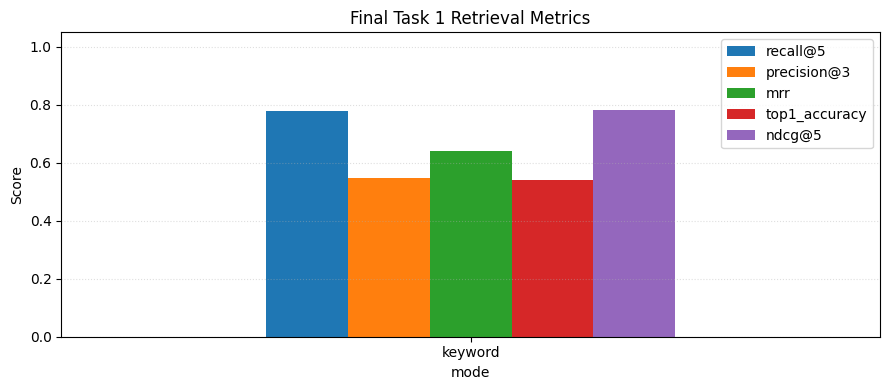

In [27]:
%matplotlib inline

import matplotlib.pyplot as plt

plot_metrics = overall_metrics.set_index("mode")[
    ["recall@5", "precision@3", "mrr", "top1_accuracy", "ndcg@5"]
]

fig, ax = plt.subplots(figsize=(9, 4))

plot_metrics.plot(
    kind="bar",
    ax=ax,
    ylim=(0, 1.05),
    rot=0
)

ax.set_title("Final Task 1 Retrieval Metrics")
ax.set_ylabel("Score")
ax.grid(axis="y", linestyle=":", alpha=0.4)

fig.tight_layout()
plt.show()

## Full showcase mode: semantic and hybrid search

The submitted metrics above are the standard marking run: a lightweight, reproducible TF-IDF baseline that does not need model downloads. The full system also supports semantic and hybrid retrieval for local showcase use.

- **Semantic search** uses MiniLM sentence embeddings to retrieve passages by meaning rather than exact vocabulary overlap.
- **Hybrid search** combines lexical TF-IDF evidence with semantic similarity, which is stronger for paraphrased queries while still respecting exact inquiry terms, recommendation numbers and named policy language.
- The same QA matrix and evaluation code are used below, so the comparison remains aligned with the submitted benchmark.

This cell is intentionally optional. If `sentence-transformers` or the MiniLM model is unavailable, it prints setup guidance and leaves the baseline results unchanged. Install `requirements-optional.txt` to run the full semantic/hybrid mode locally.


In [28]:
import importlib.util

OPTIONAL_SEARCH_COMPARISON_PATH = OUTPUTS_DIR / "search_evaluation_comparison.csv"
showcase_comparison_df = overall_metrics[metric_cols].reset_index(drop=True).copy()
showcase_comparison_df["run_status"] = "submitted_baseline"

if importlib.util.find_spec("sentence_transformers") is None:
    print("Full showcase mode not run: optional dependency 'sentence-transformers' is not installed.")
    print("Install requirements-optional.txt to run the full semantic/hybrid search mode locally.")
    print("The table below shows the standard TF-IDF marking baseline.")
    display(showcase_comparison_df)
else:
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=FutureWarning, module=r"transformers(\.|$)")
            warnings.filterwarnings("ignore", category=FutureWarning, module=r"huggingface_hub(\.|$)")
            warnings.filterwarnings("ignore", message=r".*resume_download.*", category=FutureWarning)
            warnings.filterwarnings("ignore", message=r".*Torch was not compiled with flash attention.*")
            from sentence_transformers import SentenceTransformer
            import src.search as search_module

            # Load only from the local cache so the optional showcase never emits
            # Hugging Face retry/no-network warnings in marking environments.
            local_model = SentenceTransformer(OPTIONAL_SEMANTIC_MODEL, local_files_only=True)
            search_module._ST_MODEL_CACHE[OPTIONAL_SEMANTIC_MODEL] = local_model
            showcase_embeddings = search_module.build_embeddings(search_corpus, model_name=OPTIONAL_SEMANTIC_MODEL)
        _, showcase_results_df, showcase_metrics_df = run_qa_matrix(
            data_dir=DATA_DIR,
            query_bank_path=QA_QUERY_PATH,
            chunk_size=CHUNK_SIZE,
            overlap=OVERLAP,
            top_k=5,
            modes=["keyword", "semantic", "hybrid"],
            prebuilt_corpus=search_corpus,
            prebuilt_embeddings=showcase_embeddings,
        )
        showcase_overall = showcase_metrics_df[showcase_metrics_df["query_type"] == "ALL"].copy()
        showcase_comparison_df = showcase_overall[metric_cols].reset_index(drop=True)
        showcase_comparison_df["run_status"] = "generated_locally"
        showcase_comparison_df.to_csv(OPTIONAL_SEARCH_COMPARISON_PATH, index=False)
        print(f"Full semantic/hybrid showcase comparison saved to {OPTIONAL_SEARCH_COMPARISON_PATH.relative_to(PROJECT_ROOT)}")
        display(showcase_comparison_df)
    except Exception as exc:
        print(f"Full showcase mode skipped: optional MiniLM model is not available locally ({type(exc).__name__}: {exc})")
        print("The standard TF-IDF marking baseline remains valid and reproducible.")
        display(showcase_comparison_df)


Full semantic/hybrid showcase comparison saved to outputs\search_evaluation_comparison.csv


,mode,n_queries,recall@1,recall@3,recall@5,precision@3,mrr,top1_accuracy,doc_accuracy,ndcg@5,run_status
0,hybrid,50,0.70,0.76,0.84,0.633,0.742,0.70,0.78,0.819,generated_locally
1,keyword,50,0.54,0.72,0.78,0.547,0.642,0.54,0.76,0.781,generated_locally
2,semantic,50,0.72,0.86,0.90,0.667,0.787,0.72,0.78,0.858,generated_locally


### Result Interpretation

The TF-IDF baseline is transparent and reproducible: it performs best when queries share distinctive terms with the target passages, such as named policies, inquiry topics, exact recommendation phrases or dates. The full semantic/hybrid mode is the stronger local showcase path for harder cases where relevant passages use paraphrase or broader narrative wording. It uses the same corpus and QA matrix, but depends on optional MiniLM dependencies that are deliberately kept out of the default marking setup.

For final marking, the important evidence is that the notebook defines the corpus, explains the searchable unit, states the relevance assumptions, reports ranked-retrieval metrics and inspects failure cases rather than relying on anecdotal examples. For full showcase review, run the optional semantic/hybrid cell above to populate and save the comparison table.


In [29]:
top1_df = top1_results_table(results_eval_df)
failures_df = failures_table(results_eval_df)

print("Top-1 result sample:")
display(
    top1_df[[
        "query_id", "query_type", "mode", "query", "returned_source",
        "returned_page", "score", "auto_relevance", "error_category",
    ]].head(12)
)

print(f"Top-1 rows not labelled relevant/likely relevant: {len(failures_df)}")
if not failures_df.empty:
    display(
        failures_df[[
            "query_id", "query_type", "mode", "query", "returned_source",
            "returned_page", "score", "auto_relevance", "error_category",
        ]].head(10)
    )


Top-1 result sample:


,query_id,query_type,mode,query,returned_source,returned_page,score,auto_relevance,error_category
0,q_ep_01,exact_phrase,keyword,full and fair financial redress,PostOfficeHorizon-I- Inquiry-Recomm.pdf,121,0.2940,likely_relevant,
1,q_ep_02,exact_phrase,keyword,"50,000 trackable pieces of orbital debris",TheSpaceEconomyReport.pdf,16,0.2121,relevant,
2,q_ep_03,exact_phrase,keyword,lack of openness transparency and candour,Volume_1-Blood-Inquiry-Recomm.pdf,17,0.1386,likely_relevant,
3,q_ep_04,exact_phrase,keyword,Recommendation 6 A regular UK-wide pandemic response exercise,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,233,0.3026,relevant,
4,q_ep_05,exact_phrase,keyword,what works are more likely to be successful than those which are not,Behaviour-Change-Report-Recomm.pdf,20,0.1141,relevant,
5,q_ps_01,paraphrase_semantic,keyword,wrongful prosecution compensation for post office employees,PostOfficeHorizon-I- Inquiry-Recomm.pdf,19,0.1544,likely_relevant,
6,q_ps_02,paraphrase_semantic,keyword,space junk threatening satellites and spacecraft collision,TheSpaceEconomyReport.pdf,97,0.1210,likely_relevant,
7,q_ps_03,paraphrase_semantic,keyword,infected blood patients were not told the truth for decades,Volume_1-Blood-Inquiry-Response.pdf,1,0.1679,irrelevant,chunk_too_small
8,q_ps_04,paraphrase_semantic,keyword,nationwide emergency simulation and pandemic preparedness drills,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,7,0.1502,likely_relevant,
9,q_ps_05,paraphrase_semantic,keyword,scientific evidence should underpin government public health campaigns,UK-Covid-19_Inquiry_Module_1_Response.pdf,36,0.1247,irrelevant,chunk_too_small


Top-1 rows not labelled relevant/likely relevant: 23


,query_id,query_type,mode,query,returned_source,returned_page,score,auto_relevance,error_category
0,q_ps_03,paraphrase_semantic,keyword,infected blood patients were not told the truth for decades,Volume_1-Blood-Inquiry-Response.pdf,1,0.1679,irrelevant,chunk_too_small
1,q_ps_05,paraphrase_semantic,keyword,scientific evidence should underpin government public health campaigns,UK-Covid-19_Inquiry_Module_1_Response.pdf,36,0.1247,irrelevant,chunk_too_small
2,q_rs_01,recommendation_specific,keyword,Post Office Horizon inquiry recommendation legal advice for claimants choosing scheme,PostOfficeHorizon-I- Inquiry-Recomm.pdf,165,0.2763,doc_match_only,chunk_too_small
3,q_rs_03,recommendation_specific,keyword,Covid inquiry recommendation on pandemic preparedness and Cabinet Office planning,UK-Covid-19-Inquiry-Module-1-Recomm.pdf,7,0.1588,partial,chunk_too_small
4,q_rs_04,recommendation_specific,keyword,infected blood inquiry recommendation on compensation authority,Volume_1-Blood-Inquiry-Response.pdf,1,0.3872,irrelevant,chunk_too_small
5,q_resp_01,response_specific,keyword,government response to Post Office financial compensation recommendation accepted,Volume_1-Blood-Inquiry-Response.pdf,1,0.2435,irrelevant,chunk_too_small
6,q_resp_02,response_specific,keyword,government response to space economy report recommendations,Volume_1-Blood-Inquiry-Response.pdf,1,0.2952,irrelevant,chunk_too_small
7,q_resp_03,response_specific,keyword,government response to pandemic exercise preparedness recommendation accepted in principle,Volume_1-Blood-Inquiry-Response.pdf,13,0.2725,irrelevant,chunk_too_small
8,q_resp_05,response_specific,keyword,government response to behaviour change report on evidence-based policy,Volume_1-Blood-Inquiry-Response.pdf,1,0.2620,irrelevant,chunk_too_small
9,q_pt_01,policy_topic,keyword,wrongful criminal conviction accountability miscarriage of justice,PostOfficeHorizon-I- Inquiry-Recomm.pdf,27,0.0990,partial,chunk_too_small


## 9. Challenges And Resolutions

### Challenge 1: Noisy PDF structure

**Problem.** Parliamentary and inquiry PDFs contain title pages, contents pages, metadata, headers, footers and page-number artefacts.

**Why it mattered.** If these artefacts enter the index, a search query can retrieve navigation text rather than a substantive policy passage.

**Solution.** The preprocessing pipeline removes likely non-content pages and repeated lines, normalises extracted text and preserves page provenance for inspection.

**Evidence/result.** The extraction audit reports retained pages, median page word counts, short-page counts and previews for every PDF before indexing. This gives visible evidence that the index is built from body text rather than raw PDF dumps.

**Remaining limitation.** OCR quality depends on the local Tesseract installation; if unavailable, image-only pages are skipped rather than causing notebook failure.

### Challenge 2: Choosing a useful passage size

**Problem.** Whole-document search is too coarse, while very short chunks lose context and rank poorly.

**Why it mattered.** Task 1 asks users to find relevant passages, so the system must return focused spans that still contain enough context to be interpretable.

**Solution.** The final index uses 400-word chunks, 50-word overlap and short-chunk merging below 60 words, while retaining document and page metadata.

**Evidence/result.** The chunk summary reports chunk counts and word-length ranges per document, and the notebook reports how many chunks remain below the minimum threshold after merging.

**Remaining limitation.** Word-window chunking can still split a long argument across adjacent chunks; neighbouring context in the widget mitigates this for users.

### Challenge 3: Evaluating retrieval without a large manual judgement set

**Problem.** The coursework dataset does not include a full passage-level relevance benchmark for Task 1.

**Why it mattered.** A search demo alone would not prove ranking quality or show where the system fails.

**Solution.** The notebook uses a fixed 50-query QA matrix with expected documents, keywords and anchor phrases. Results are labelled automatically from transparent signals and evaluated with ranked metrics.

**Evidence/result.** The final evaluation tables report Recall@k, Precision@3, MRR, top-1 accuracy, document accuracy and nDCG@5, plus a failure table for weaker cases.

**Remaining limitation.** Automatic labels are less authoritative than exhaustive human relevance judgements; they are suitable for coursework-scale evaluation but could be strengthened with manual annotation.

### Challenge 4: Lexical mismatch and paraphrase

**Problem.** TF-IDF can miss relevant passages that discuss the same idea using different wording.

**Why it mattered.** The document collection includes policy responses and inquiry reports where recommendations may be paraphrased rather than repeated exactly.

**Solution.** The core notebook keeps a strong, reproducible TF-IDF baseline and includes optional semantic/hybrid search for environments where MiniLM embeddings are available.

**Evidence/result.** Query-type breakdowns show which query categories are easier or harder for the lexical baseline; optional semantic/hybrid evaluation can be enabled without changing the indexing methodology.

**Remaining limitation.** The default submitted execution avoids external model-download risk, so semantic/hybrid scores are only produced when the optional dependency and model are available.


In [30]:
challenge_evidence = pd.DataFrame(
    [
        {"evidence_item": "PDFs indexed", "value": len(pdf_files)},
        {"evidence_item": "Retained pages", "value": len(page_df)},
        {"evidence_item": "Searchable chunks", "value": len(search_corpus)},
        {"evidence_item": f"Chunks below {MIN_CHUNK_WORDS} words", "value": int((chunk_df["word_count"] < MIN_CHUNK_WORDS).sum())},
        {"evidence_item": "Evaluation queries", "value": len(query_bank)},
        {"evidence_item": "Evaluation modes run", "value": ", ".join(evaluation_modes)},
        {"evidence_item": "Mean Recall@5 (keyword)", "value": float(overall_metrics.loc[overall_metrics["mode"] == "keyword", "recall@5"].iloc[0])},
        {"evidence_item": "Mean MRR (keyword)", "value": float(overall_metrics.loc[overall_metrics["mode"] == "keyword", "mrr"].iloc[0])},
    ]
)
display(challenge_evidence)


,evidence_item,value
0,PDFs indexed,10
1,Retained pages,1083
2,Searchable chunks,1661
3,Chunks below 60 words,32
4,Evaluation queries,50
5,Evaluation modes run,keyword
6,Mean Recall@5 (keyword),0.78
7,Mean MRR (keyword),0.642


## 10. Limitations And Future Work

- Add human passage-level relevance labels to strengthen the evaluation beyond automatic document/keyword/anchor assumptions.
- Improve OCR quality checks for scanned PDFs by comparing OCR text against a small manual sample.
- Run the optional semantic/hybrid mode with a cached MiniLM model for paraphrase-heavy queries.
- Add query expansion or a BM25 retriever as a lightweight alternative to dense embeddings.
- Update the evaluation query bank if additional PDFs or custom documents are added to `data/raw`.


## 11. Citations And Acknowledgements

This Task 1 notebook uses the following external libraries and resources:

- **PyMuPDF (`pymupdf`)** for PDF text extraction.
- **pandas** and **NumPy** for tabular data handling and numerical summaries.
- **scikit-learn** for TF-IDF vectorisation and cosine-similarity retrieval.
- **matplotlib** for evaluation plots.
- **ipywidgets** for the interactive search demonstration.
- Optional **sentence-transformers** / **all-MiniLM-L6-v2** for semantic and hybrid retrieval if enabled.

The document collection and coursework requirements come from the COP509 coursework brief.


## 12. Task 1 Compliance Summary

| Task 1 marking area | Evidence in this notebook |
|---|---|
| Text extraction and preprocessing | Preset-driven PDF discovery, extraction audit, retained-page summaries and preprocessing explanation |
| Search implementation | Passage chunking, reproducible TF-IDF baseline, and full semantic/hybrid showcase mode |
| Varied queries | 50-query QA matrix focused on the 5-pair / 10-PDF coursework search evaluation corpus |
| Evaluation methodology and results | Relevance assumptions, ranked metrics, final tables, plot and failure inspection |
| Interactive demo | `ipywidgets` search interface plus static example for PDF export |
| Challenges | Clearly labelled challenge/resolution section with evidence and remaining limitations |
| Documentation | Tutorial-style explanations, reproducibility notes and local showcase instructions |